# Landsat images

Peter Ralph  
2026-03-02

# Data: Landsat images

## 

> The [NASA/USGS Landsat
> program](https://science.nasa.gov/mission/landsat/) provides the
> longest continuous space-based record of Earth’s land in existence.
> Landsat data are essential for making informed decisions about our
> planet’s resources and environment.

<figure>
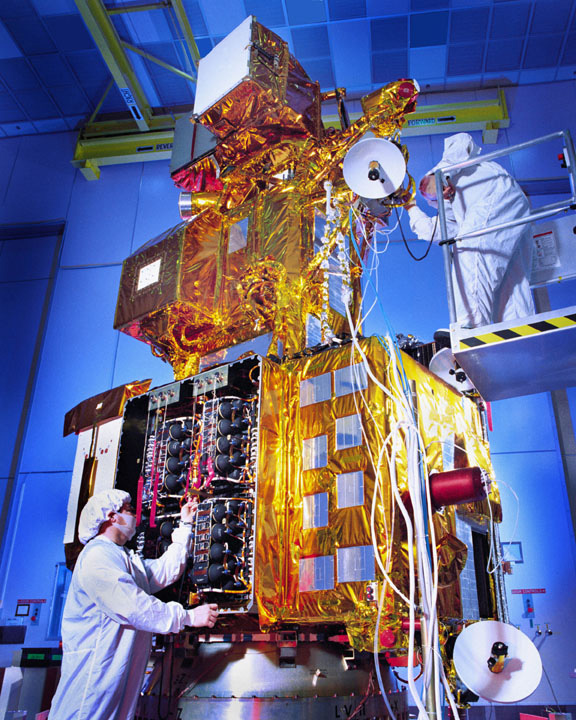
<figcaption aria-hidden="true">picture of a landsat sattelite from NASA
via Wikimedia Commons</figcaption>
</figure>

## 

Data (Landsat 8/9):

-   700 scenes/day, 185km wide
-   11 spectral bands from a [multispectral
    scanner](https://en.wikipedia.org/wiki/Multispectral_Scanner)
-   15m/30m/100m pixels

<figure>
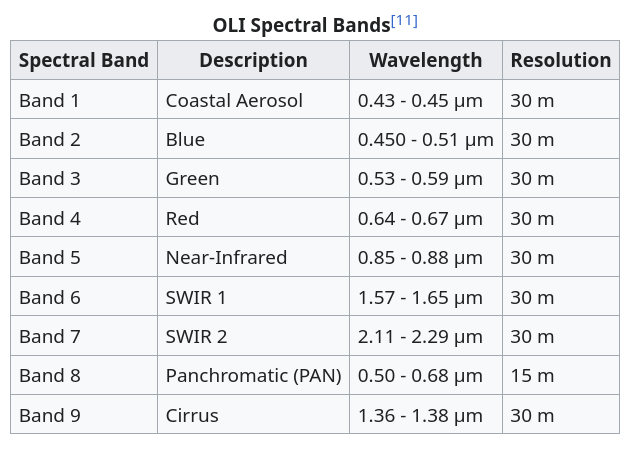
<figcaption aria-hidden="true">table of bands from <a
href="https://en.wikipedia.org/wiki/Landsat_8">Wikipedia</a></figcaption>
</figure>

<figure>
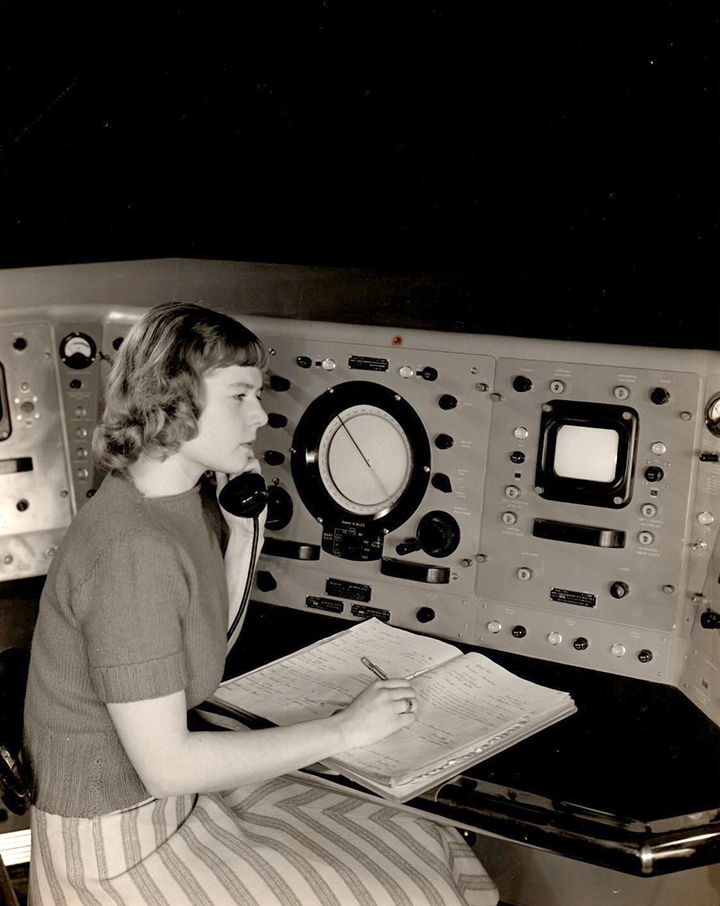
<figcaption aria-hidden="true">photo of Virginia Norwood from
https://landsat.gsfc.nasa.gov/article/virginia-t-norwood-mother-landsat</figcaption>
</figure>

[Virginia Norwood](https://en.wikipedia.org/wiki/Virginia_T._Norwood)

## Obtaining the data

It’s free: from
[earthexplorer.usgs.gov](https://earthexplorer.usgs.gov/)

as
[GeoTIFF](https://blogs.loc.gov/maps/2023/05/the-secret-life-of-geotiffs/)
raster files

and there’s a LOT of it: each scene is ~1G

``` sh
$ ls -lath *.tar
-rw-rw-r-- 1 peter peter 948M Mar  1 08:33 LC08_L2SP_046029_20250602_20250607_02_T1.tar
-rw-rw-r-- 1 peter peter 962M Mar  1 08:29 LC08_L2SP_046029_20200604_20200825_02_T1.tar
```

<figure>
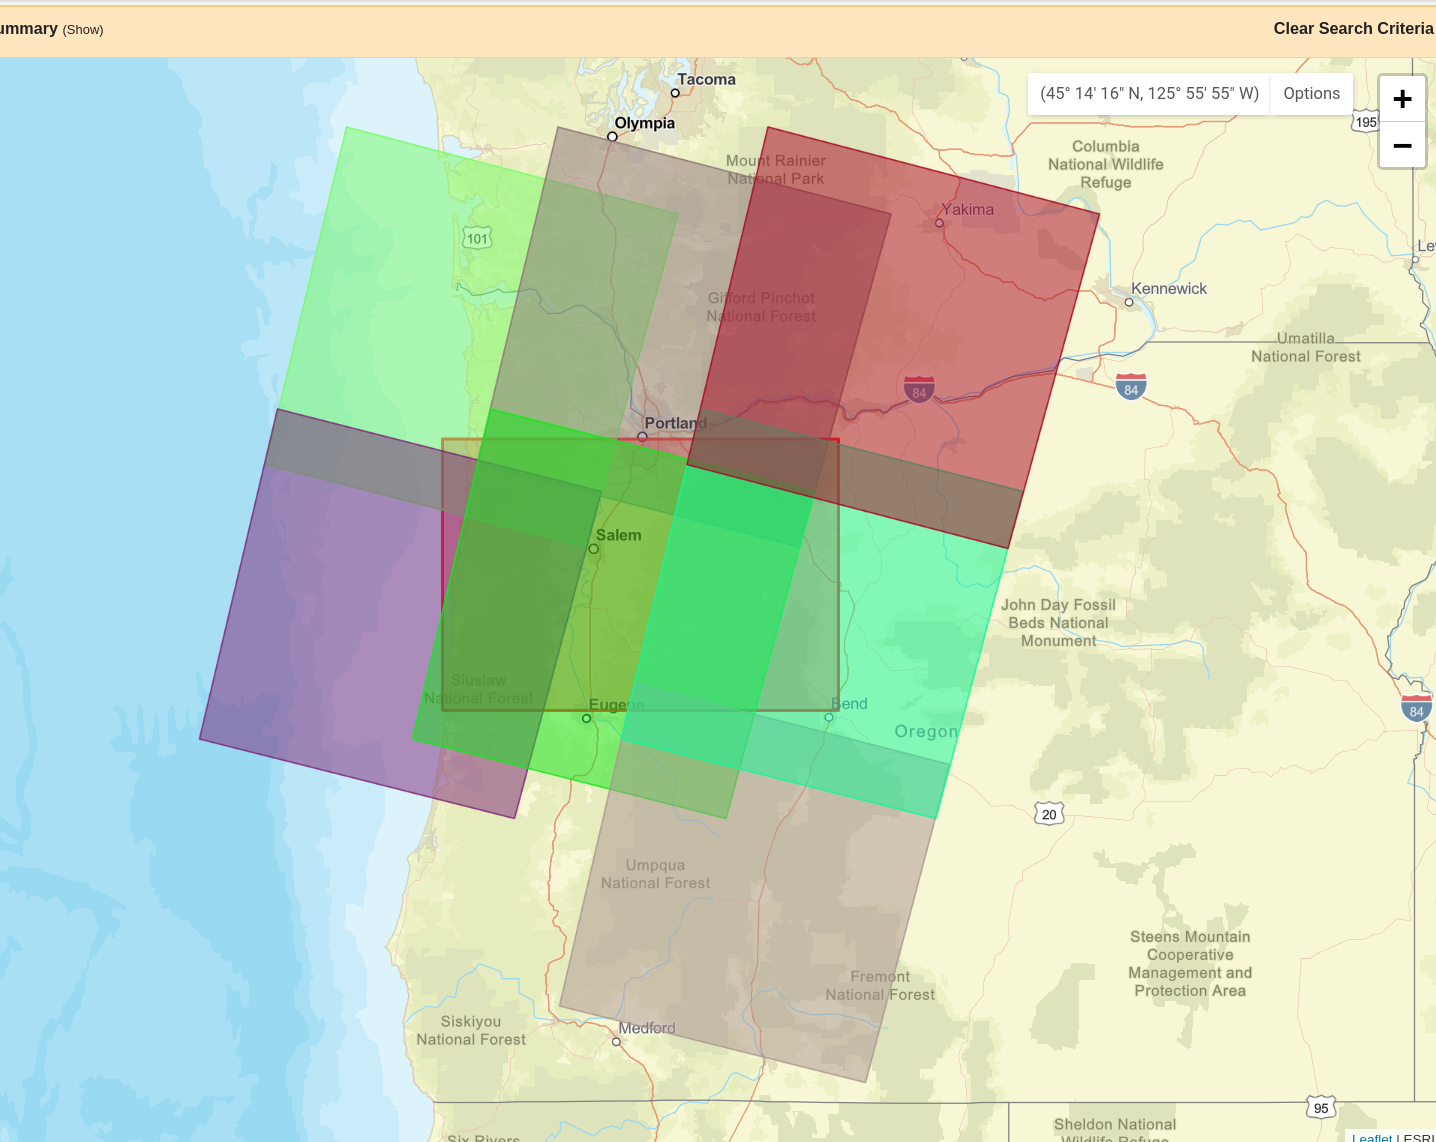
<figcaption aria-hidden="true">screenshot of map from
earthexplorer</figcaption>
</figure>

# Raster data in python

Some good references:

-   the [rasterio
    docs](https://rasterio.readthedocs.io/en/stable/quickstart.html)
-   [geocomputation with
    python](https://py.geocompx.org/02-attribute-operations#sec-manipulating-raster-objects)

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pyproj
import contextily
import json
import matplotlib.pyplot as plt
import shapely
import rasterio
import rasterio.plot
import rasterio.mask

## Files

I’ve picked a day without a lot of clouds (Aug 25, 2020), downloaded the
data above Eugene, unpackaged the tar archive and put the basic bands,
cropped somewhat for file size, in [data/landsat](data/landsat):

-   [Metadata file for
    bands](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_MTL.json)
-   [Band
    1](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B1.TIF)
-   [Band
    2](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B2.TIF)
-   [Band
    3](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B3.TIF)
-   [Band
    4](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B4.TIF)
-   [Band
    5](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B5.TIF)
-   [Band
    6](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B6.TIF)
-   [Band
    7](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_SR_B7.TIF)
-   [thumbnail,
    large](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_thumb_large.jpeg)
-   [thumbnail,
    small](data/landsat/LC08_L2SP_046029_20200604_20200825_02_T1_thumb_small.jpeg)

## Metadata

You’ll need to get the data, linked on the previous slide or from
[github](https://github.com/UOdsci/ds435/tree/main/data/landsat), and
put it in the `data/landsat/` subdirectory.

This comes with a JSON metadata file:

In [ ]:
ddir = "data/landsat"
fname = "LC08_L2SP_046029_20200604_20200825_02_T1"
with open(f"{ddir}/{fname}_MTL.json", "r") as f:
    md = json.loads(f.read())

list(md['LANDSAT_METADATA_FILE'].keys())

## Of note: file names

In [ ]:
md['LANDSAT_METADATA_FILE']['PRODUCT_CONTENTS']

## Opening a raster:

In [ ]:
band5 = rasterio.open(ddir + "/" + md['LANDSAT_METADATA_FILE']['PRODUCT_CONTENTS']['FILE_NAME_BAND_5'])
band5.shape

In [ ]:
band5.meta

## Viewing the raster:

In [ ]:
fig, ax = plt.subplots()
rasterio.plot.show(band5, ax=ax)
ax.set_title("Band 5");

## Viewing the raster, in context:

Note the `crs`!

In [ ]:
bbox = gpd.GeoSeries(shapely.geometry.box(*band5.bounds), crs=band5.crs)

fig, ax = plt.subplots(figsize=(10,10))
bbox.plot(ax=ax, alpha=0)
contextily.add_basemap(ax, crs=band5.crs)
rasterio.plot.show(band5, ax=ax, alpha=0.5)
ax.set_title("Band 5");

## Values:

`raster.read()` gets a numpy array of the values. Note the *missing
data*:

In [ ]:
plt.hist(
    band5.read().flatten(),
    bins=100,
);

# Now, let’s explore!

*Things we won’t talk about:* (see [the
docs](resources/LSDS-1619_Landsat8-9-Collection2-Level2-Science-Product-Guide-v6.pdf)
for a lot more!)

-   USGS provides lots of downstream data products! Sophisticated
    combinations of bands to help:

    -   ignore clouds
    -   get useful real-world measurements (snow cover, thermal
        upwelling…)

-   What the spectral bands “mean”

-   How these bands relate to what we see

-   What people usually use this data for

## Goals:

Basically, “make a nice picture”.

Concretely: make a map where color communicates something important
about land type.

Two possible workflows:

1.  Pick a few ‘different’ locations on the map; find some combinations
    of bands that distinguish those; map these to colors.

2.  Do PCA, and map the PCs to colors.

## A quick reminder about “colorspace”:

-   Human retinas most commonly have three kinds of color-sensitive
    photoreceptors.
-   So, our color perception is “three-dimensional”.
-   Printing: RGB (e.g.,
    \#<span style="color: red;">3A</span><span style="color: green;">11</span><span style="color: blue;">FF</span>;)
    or CMYK
-   Perception: [HSL and HSV](https://en.wikipedia.org/wiki/HSL_and_HSV)
-   **Plus:** transparancy, or `alpha`:
    \#<span style="color: #FF0000FF;">3A</span><span style="color: #00FF00FF;">11</span><span style="color: #0000FFFF;">FF</span><span style="color: #00000088;">00</span>;
-   On computer monitors, RGB values range from 0 to 255.

So, by “make an image” we mean “make 1 to 3 rectangular arrays of
integers between 0 and 255”.

<figure>
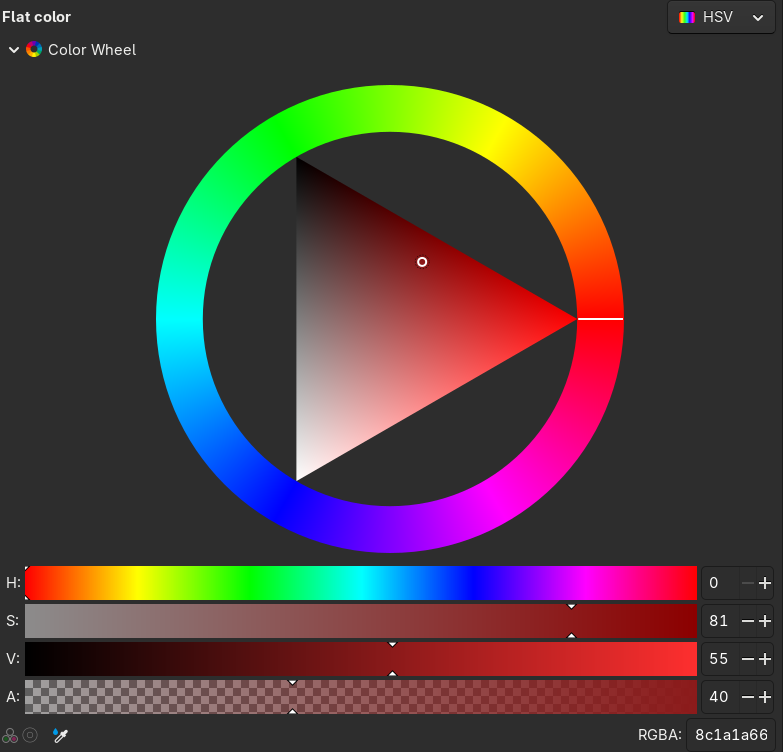
<figcaption aria-hidden="true">screenshot of a color picker in HSV
space</figcaption>
</figure>

## Brainstorming:

1.  Pick a few ‘different’ locations on the map; find some combinations
    of bands that distinguish those; map these to colors.

2.  Do PCA, and map the PCs to colors.

-   What is the difference between these?
-   How would we actually do (1)?
-   How would we actually do (2)?

# Tools

We could just reduce the landsat images to arrays, but we’d like to
maintain spatial context.

So, we’ll need to:

-   Extract values from all the bands at particular locations.
-   Extract values from all the bands averaged across polygons (e.g., a
    circle around a location).
-   Combine together bands arithmetically.
-   Turn the result into an image.

## Get the bands in order:

*Note:* beware; trying to do some things with all of these (e.g., plot
them all) might crash your browser.

In [ ]:
band_names = [f"BAND_{k}" for k in range(1,7)]
file_names = {
    bn : ddir + "/" + md['LANDSAT_METADATA_FILE']['PRODUCT_CONTENTS']["FILE_NAME_" + bn]
    for bn in band_names
}
bands = { bn: rasterio.open(file_names[bn]) for bn in band_names }

# Working with layers

First let’s look at mapping values to images, and rescaling.

## Low contrast?

In [ ]:
fig, ax = plt.subplots()
rasterio.plot.show(band5, ax=ax)
ax.set_title("Band 5");

## Well, that makes sense:

In [ ]:
values = band5.read(masked=True).squeeze()
print('data:', values.data.shape, 'mask:', values.mask.shape)
plt.hist(values.data[~values.mask], bins=100);

## Let’s rescale!

And, let’s work with just numpy arrays for a bit.

In [ ]:
plt.imshow(values)

## Rescaling:

And, let’s work with just numpy arrays for a bit.

In [ ]:
a, b = np.quantile(values.data[~values.mask], q=[0.05, 0.95])
values = (values - a) / (b - a)
values = np.minimum(1.0, np.maximum(0.0, values))
values = (255 * values).astype(int)
plt.imshow(values)

## How about in color?

In [ ]:
def norm_values(bn):
    values = bands[bn].read(masked=True)
    a, b = np.quantile(values.data[~values.mask], q=[0.05, 0.95])
    values = 255*(values - a)/(b - a)
    values[values<0] = 0
    values[values>255] = 255
    return values.astype(int)
    
values = np.ma.array([norm_values(bn) for bn in ["BAND_5", "BAND_6", "BAND_3"]]).squeeze()
values = np.moveaxis(values, [0, 1, 2], [2, 0, 1])
print('values:', values.shape)
plt.imshow(values);

## Putting this back on a map:

All it takes is the right `transform` argument!

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
bbox.plot(ax=ax, alpha=0)
contextily.add_basemap(ax, crs=bands["BAND_5"].crs)
rasterio.plot.show(np.moveaxis(values, [0,1,2], [1,2,0]), transform=bands["BAND_5"].transform, ax=ax, alpha=0.5);

## Or, with `ax.imshow`:

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
bbox.plot(ax=ax, alpha=0)
contextily.add_basemap(ax, crs=bands["BAND_5"].crs)
ax.imshow(values, extent=bbox.bounds[['minx', 'maxx', 'miny', 'maxy']].values[0], alpha=0.5);
ax.set_title("Band 5");

# Extracting values

We’ll do this “by hand”; another method would use
[rasterstats](https://pythonhosted.org/rasterstats/).

First: pick some points:

In [ ]:
npts = 10
pts = bbox.sample_points(npts, seed=123)
pd.concat([pts, bbox]).explore()

## Pour one out for the NAs

Some of the points will be outside the area of the raster:

In [ ]:
bn = 'BAND_5'
xyz = pts.get_coordinates()
xyz[bn] = np.array(list(bands[bn].sample([xy[1:] for xy in xyz.itertuples()]))).flatten()
xyz

## Rejection sampling:

Let’s sample more than we need and restrict to ones coved by the data:

In [ ]:
pts = bbox.sample_points(2*npts, seed=123).explode(index_parts=True)[0]
xyz = pts.get_coordinates()
xyz[bn] = np.array(list(bands[bn].sample([xy[1:] for xy in xyz.itertuples()]))).flatten()
pts = pts.loc[xyz[bn] > 0][:npts]
pd.concat([pts, bbox]).explore()

## Extracting values from circles

A single pixel seems kinda… noisy? Let’s take averages within some
buffer around each point.

In [ ]:
pts = pts.buffer(5000)
pd.concat([pts, bbox]).explore()

## 

Of use: `mask`

In [ ]:
im, mask = rasterio.mask.mask(
    bands['BAND_5'], 
    [pts.iloc[0]],
    crop=True,
    filled=False,
)
print("shape: {im.shape}")
plt.imshow(im.squeeze());

## Let’s get some tooling together:

1.  Write a fuction that gets average values in each of a bunch of
    polygons from a band.
2.  Apply that function to each of our bands.

In [ ]:
def zonal_means(pts, band):
    pass

point_data = gpd.GeoDataFrame(pts)